In [42]:
import os
os.chdir(r"D:\OneDrive\Desktop\Checkout_Capstone")
os.getcwd()


'D:\\OneDrive\\Desktop\\Checkout_Capstone'

loading csv files

In [43]:
import pandas as pd


fact_sessions = pd.read_csv("data/fact_sessions.csv")
fact_orders = pd.read_csv("data/fact_orders.csv")
dim_users = pd.read_csv("data/dim_users_enriched.csv")


print("Data loaded successfully")


Data loaded successfully


In [44]:
fact_sessions.head()

,session_id,user_id,start_ts,device,channel,campaign_id,variant,is_new_user,add_to_cart,begin_checkout,...,purchase,has_product_view,has_add_to_cart,has_begin_checkout,has_payment_attempt,has_purchase,time_to_cart_sec,time_to_checkout_sec,time_to_purchase_sec,session_duration_sec
0,s0000001,u001627,2025-10-26 15:56:31,web,organic,c025,a,1,NaN,NaN,...,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0
1,s0000002,u001038,2025-12-09 21:56:53,mobile,paid_social,c037,NaN,0,NaN,NaN,...,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0
2,s0000003,NaN,2025-11-24 21:24:21,web,organic,c034,NaN,0,NaN,NaN,...,NaN,1,0,0,0,0,NaN,NaN,NaN,23.0
3,s0000004,u001072,2025-12-02 06:51:38,mobile,organic,c013,NaN,0,NaN,NaN,...,NaN,0,0,0,0,0,NaN,NaN,NaN,0.0
4,s0000005,u001301,2025-11-28 16:03:05,mobile,paid_social,c004,NaN,1,NaN,NaN,...,NaN,1,0,0,0,0,NaN,NaN,NaN,100.0


In [45]:
fact_orders.head()

,order_id,session_id,user_id,order_ts,gross_amount,discount_amount,shipping_amount,net_amount,payment_method,total_items,distinct_products,total_cost,avg_product_rating,top_category,margin_proxy
0,o0000001,s0000015,u000739,2026-01-12 14:51:51,4145.06,49.97,0.00,4095.09,upi,5,3,2580.45,4.233333,books,1514.64
1,o0000002,s0000060,NaN,2025-11-19 07:56:21,4302.50,151.09,0.00,4151.41,netbanking,5,3,2819.76,3.900000,books,1331.65
2,o0000003,s0000073,NaN,2025-12-08 05:40:42,7199.78,596.95,0.00,6602.83,netbanking,2,1,4502.68,4.100000,books,2100.15
3,o0000004,s0000081,u001896,2025-12-09 11:00:54,1262.26,75.40,117.27,1304.13,wallet,2,1,614.50,4.900000,electronics,689.63
4,o0000005,s0000084,u002032,2025-11-01 02:02:38,13486.98,1087.51,0.00,12399.47,upi,7,4,8519.26,4.100000,sports,3880.21


In [46]:
dim_users.head()

,user_id,signup_date,city_tier,segment,preferred_device,lifetime_sessions,lifetime_orders,first_order_date,last_order_date,repeat_rate_flag,lifetime_revenue,user_value_band
0,u000001,2025-07-16,1,premium,mobile,3.0,0.0,NaN,NaN,0,0.00,low
1,u000002,2025-12-29,3,regular,mobile,5.0,1.0,2025-11-14 09:34:01,2025-11-14 09:34:01,0,11632.70,high
2,u000003,2025-11-26,3,value,mobile,2.0,0.0,NaN,NaN,0,0.00,low
3,u000004,2025-09-01,2,value,mobile,5.0,1.0,2025-11-06 14:06:09,2025-11-06 14:06:09,0,9153.61,high
4,u000005,2025-10-06,1,regular,web,2.0,0.0,NaN,NaN,0,0.00,low


Part C — Analytics (Insights + KPIs) ||
    Funnel Diagnosis |
     KPI Trends |
    Segment Deep Dive |
    Drop-off Investigation ||

funnel diagnosis + root cause

overall funnel 

In [49]:
funnel_metrics = {
    "product_view": fact_sessions["has_product_view"].sum(),
    "add_to_cart": fact_sessions["has_add_to_cart"].sum(),
    "begin_checkout": fact_sessions["has_begin_checkout"].sum(),
    "payment_attempt": fact_sessions["has_payment_attempt"].sum(),
    "purchase": fact_sessions["has_purchase"].sum()
}

funnel_df = pd.DataFrame.from_dict(funnel_metrics, orient="index", columns=["count"])
funnel_df

,count
product_view,5641
add_to_cart,1597
begin_checkout,1000
payment_attempt,1000
purchase,707


step conversion 

In [50]:
step_conversion = {
    "View → Cart": funnel_metrics["add_to_cart"] / funnel_metrics["product_view"],
    "Cart → Checkout": funnel_metrics["begin_checkout"] / funnel_metrics["add_to_cart"],
    "Checkout → Payment": funnel_metrics["payment_attempt"] / funnel_metrics["begin_checkout"],
    "Payment → Purchase": funnel_metrics["purchase"] / funnel_metrics["payment_attempt"]
}

step_df = pd.DataFrame(step_conversion.items(), columns=["Step","Conversion"])
step_df

,Step,Conversion
0,View → Cart,0.283106
1,Cart → Checkout,0.626174
2,Checkout → Payment,1.000000
3,Payment → Purchase,0.707000


The largest drop occurs at View → Cart (28%), indicating most users abandon before adding products to cart. This suggests issues in product page experience, pricing perception, or relevance rather than checkout flow itself.

root cause using time metrics

In [51]:
fact_sessions.groupby("has_add_to_cart")["time_to_cart_sec"].median()

has_add_to_cart
0     NaN
1    64.0
Name: time_to_cart_sec, dtype: float64

device and channel root cause

In [54]:
fact_sessions.groupby("device")["has_add_to_cart"].mean()


device
mobile     0.163677
unknown    0.111111
web        0.189811
Name: has_add_to_cart, dtype: float64

In [53]:
fact_sessions.groupby("channel")["has_add_to_cart"].mean()

channel
email          0.187348
organic        0.170283
paid_social    0.165952
referral       0.184297
search         0.187586
Name: has_add_to_cart, dtype: float64

KPI trends (weekly)

creating week column

In [62]:
fact_sessions["week"] = pd.to_datetime(fact_sessions["start_ts"]).dt.to_period("W")

weekly session KPIs

In [63]:
weekly_sessions = fact_sessions.groupby("week").agg(
    sessions=("session_id","count"),
    product_view_rate=("has_product_view","mean"),
    add_to_cart_rate=("has_add_to_cart","mean"),
    checkout_rate=("has_begin_checkout","mean"),
    purchase_rate=("has_purchase","mean"),
    avg_session_duration=("session_duration_sec","mean")
).reset_index()

weekly_sessions.head()

,week,sessions,product_view_rate,add_to_cart_rate,checkout_rate,purchase_rate,avg_session_duration
0,2025-10-20/2025-10-26,557,0.631957,0.175943,0.105925,0.070018,69.109515
1,2025-10-27/2025-11-02,672,0.626488,0.171131,0.108631,0.080357,69.870536
2,2025-11-03/2025-11-09,723,0.626556,0.172891,0.106501,0.071923,68.000000
3,2025-11-10/2025-11-16,698,0.597421,0.147564,0.087393,0.064470,63.454155
4,2025-11-17/2025-11-23,712,0.625000,0.162921,0.103933,0.078652,68.585674


weekly Revenue kpi

In [64]:
session_revenue = fact_orders.groupby("session_id")["net_amount"].sum().reset_index()

fact_sessions_rev = fact_sessions.merge(
    session_revenue,
    on="session_id",
    how="left"
)

fact_sessions_rev["net_amount"] = fact_sessions_rev["net_amount"].fillna(0)

weekly_revenue = fact_sessions_rev.groupby("week").agg(
    revenue_per_session=("net_amount","mean")
).reset_index()

weekly_revenue.head()

,week,revenue_per_session
0,2025-10-20/2025-10-26,445.704291
1,2025-10-27/2025-11-02,733.647887
2,2025-11-03/2025-11-09,441.763458
3,2025-11-10/2025-11-16,444.532650
4,2025-11-17/2025-11-23,570.631643


AOV + items per day

In [65]:
orders_with_week = fact_orders.merge(
    fact_sessions[["session_id","week"]],
    on="session_id"
)

weekly_orders = orders_with_week.groupby("week").agg(
    aov=("net_amount","mean"),
    items_per_order=("total_items","mean")
).reset_index()

weekly_orders.head()

,week,aov,items_per_order
0,2025-10-20/2025-10-26,6365.571538,4.948718
1,2025-10-27/2025-11-02,9129.840370,5.277778
2,2025-11-03/2025-11-09,6142.211154,4.653846
3,2025-11-10/2025-11-16,6895.195333,4.888889
4,2025-11-17/2025-11-23,7255.173750,4.964286


weekly order kpi

In [66]:
orders_with_week = fact_orders.merge(
    fact_sessions[["session_id","week"]],
    on="session_id"
)

weekly_orders = orders_with_week.groupby("week").agg(
    aov=("net_amount","mean"),
    items_per_order=("total_items","mean")
).reset_index()

combining all kpis

In [67]:
weekly_kpis = (
    weekly_sessions
    .merge(weekly_revenue, on="week")
    .merge(weekly_orders, on="week")
)

weekly_kpis

,week,sessions,product_view_rate,add_to_cart_rate,checkout_rate,purchase_rate,avg_session_duration,revenue_per_session,aov,items_per_order
0,2025-10-20/2025-10-26,557,0.631957,0.175943,0.105925,0.070018,69.109515,445.704291,6365.571538,4.948718
1,2025-10-27/2025-11-02,672,0.626488,0.171131,0.108631,0.080357,69.870536,733.647887,9129.840370,5.277778
2,2025-11-03/2025-11-09,723,0.626556,0.172891,0.106501,0.071923,68.000000,441.763458,6142.211154,4.653846
3,2025-11-10/2025-11-16,698,0.597421,0.147564,0.087393,0.064470,63.454155,444.532650,6895.195333,4.888889
4,2025-11-17/2025-11-23,712,0.625000,0.162921,0.103933,0.078652,68.585674,570.631643,7255.173750,4.964286
5,2025-11-24/2025-11-30,680,0.661765,0.180882,0.114706,0.082353,70.988235,554.859603,6737.580893,4.964286
6,2025-12-01/2025-12-07,689,0.628447,0.178520,0.113208,0.075472,69.294630,484.820174,6423.867308,4.673077
7,2025-12-08/2025-12-14,640,0.664062,0.206250,0.121875,0.098437,75.500000,1327.730484,13488.055714,5.063492
8,2025-12-15/2025-12-21,760,0.647368,0.171053,0.106579,0.071053,69.109211,494.958947,6966.088889,5.129630
9,2025-12-22/2025-12-28,712,0.609551,0.193820,0.125000,0.078652,70.928371,603.235632,7669.710179,5.017857


conversion funnel trend 

<Axes: xlabel='week'>

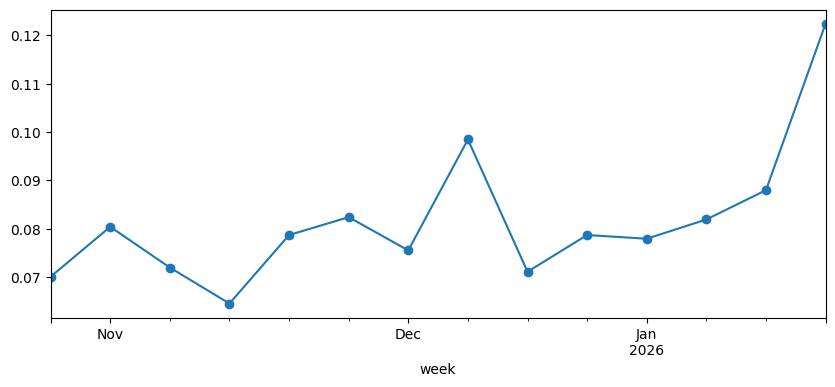

In [80]:
weekly_kpis.set_index("week")["purchase_rate"].plot(figsize=(10,4), marker='o')

add-to-cart vs purchase

<Axes: xlabel='week'>

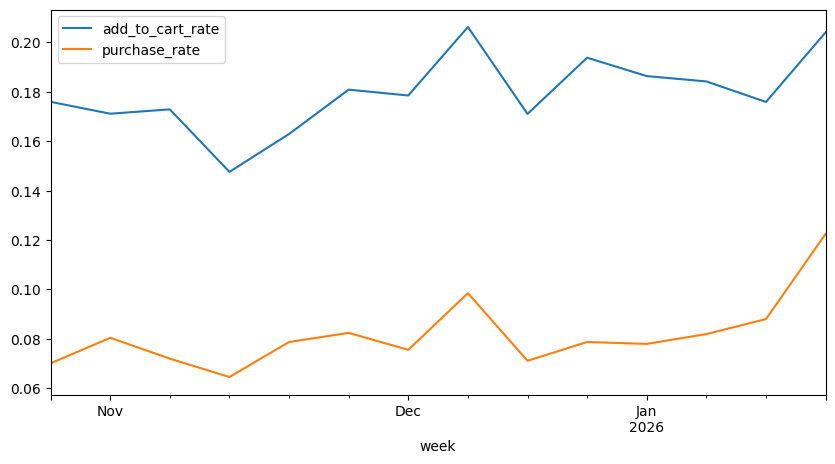

In [81]:
weekly_kpis.set_index("week")[["add_to_cart_rate","purchase_rate"]].plot(figsize=(10,5))

revenue per session trend 

<Axes: xlabel='week'>

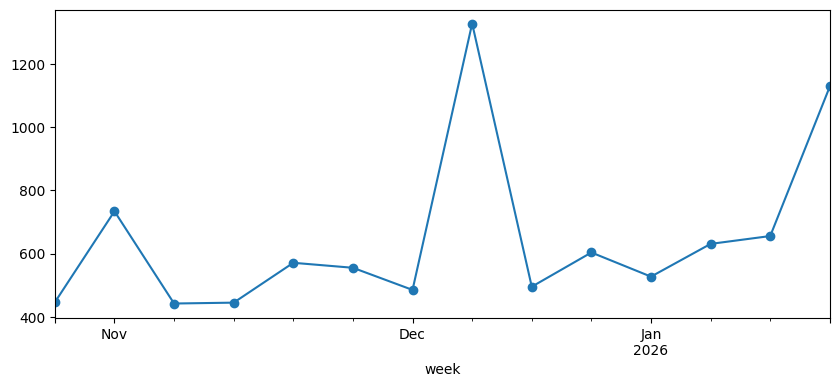

In [82]:
weekly_kpis.set_index("week")["revenue_per_session"].plot(figsize=(10,4), marker='o')

AOV trend

<Axes: xlabel='week'>

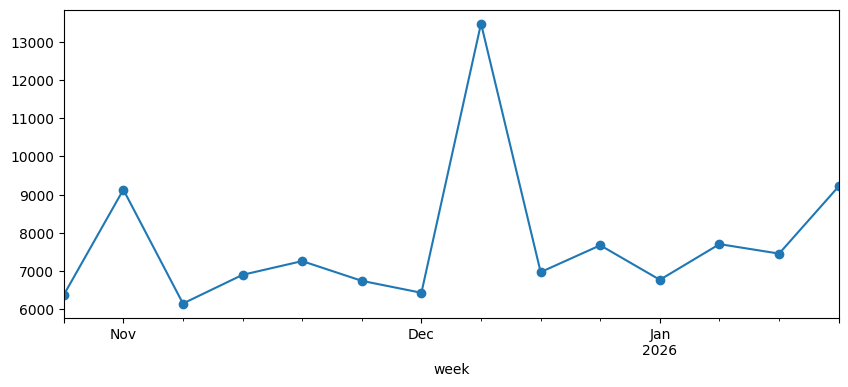

In [83]:
weekly_kpis.set_index("week")["aov"].plot(figsize=(10,4), marker='o')

Conversion peaks in Week 7 (9.8%) driven by high AOV. Weeks 3–4 show dip aligned with lower add-to-cart rate, suggesting upstream friction

SEGMENT DEEP DRIVE

In [68]:
fact_sessions_rev.groupby(["device","channel"])["has_purchase"].mean().sort_values(ascending=False)

device   channel    
unknown  paid_social    0.166667
web      search         0.100418
         organic        0.092727
         email          0.090630
         referral       0.088409
         paid_social    0.088065
mobile   search         0.069430
unknown  search         0.066667
mobile   organic        0.061448
         email          0.061296
         referral       0.057214
         paid_social    0.054974
unknown  organic        0.040000
         email          0.000000
         referral       0.000000
Name: has_purchase, dtype: float64

In [69]:
fact_sessions_rev.groupby(["device","channel"])["net_amount"].mean().sort_values(ascending=False)

device   channel    
web      organic        910.598115
         search         711.111582
         paid_social    707.516118
         referral       616.789136
         email          603.447266
mobile   referral       539.464080
unknown  search         514.918667
mobile   search         478.610031
         organic        432.856935
         email          428.234921
unknown  organic        393.335600
mobile   paid_social    349.630471
unknown  paid_social    342.621667
         email            0.000000
         referral         0.000000
Name: net_amount, dtype: float64

Drop - Off Investigation table

Calculate drop - off

In [70]:
view_to_cart = 1 - (funnel_metrics["add_to_cart"] / funnel_metrics["product_view"])
payment_to_purchase = 1 - (funnel_metrics["purchase"] / funnel_metrics["payment_attempt"])

view_to_cart, payment_to_purchase

(np.float64(0.7168941677007623), np.float64(0.29300000000000004))

identify top contributing segments

for cart drop

In [71]:
fact_sessions.groupby(["device","channel"])["has_add_to_cart"].mean().sort_values()

device   channel    
unknown  organic        0.080000
         email          0.090909
         search         0.133333
mobile   paid_social    0.151832
         organic        0.156547
unknown  paid_social    0.166667
         referral       0.166667
mobile   email          0.169877
         search         0.174093
         referral       0.176617
web      paid_social    0.178447
         organic        0.183030
         referral       0.190570
         search         0.199163
         email          0.204301
Name: has_add_to_cart, dtype: float64

for purchase drop

In [72]:
fact_sessions.groupby(["device","channel"])["has_purchase"].mean().sort_values()

device   channel    
unknown  email          0.000000
         referral       0.000000
         organic        0.040000
mobile   paid_social    0.054974
         referral       0.057214
         email          0.061296
         organic        0.061448
unknown  search         0.066667
mobile   search         0.069430
web      paid_social    0.088065
         referral       0.088409
         email          0.090630
         organic        0.092727
         search         0.100418
unknown  paid_social    0.166667
Name: has_purchase, dtype: float64

median time before drop

for cart time 

In [76]:
fact_sessions[
    fact_sessions["has_add_to_cart"] == 0
]["session_duration_sec"].median()

np.float64(15.0)

for purchase time

In [77]:
fact_sessions[
    (fact_sessions["has_payment_attempt"] == 1) &
    (fact_sessions["has_purchase"] == 0)
]["session_duration_sec"].median()

np.float64(244.0)

In [79]:
fact_sessions.groupby("is_new_user")["has_add_to_cart"].mean()

is_new_user
0    0.177372
1    0.177667
Name: has_add_to_cart, dtype: float64

PART D — A/B Experiment Analysis (Advanced)

define eligible sessions

In [89]:
eligible = fact_sessions_rev[
    fact_sessions_rev["has_product_view"] == 1
].copy()

In [90]:
eligible = fact_sessions_rev.copy()

sample size by variant

In [91]:
eligible.groupby("variant")["session_id"].nunique()

variant
a    1523
b    1474
Name: session_id, dtype: int64

conversion rate comparision

In [92]:
conv_by_variant = eligible.groupby("variant")["has_purchase"].mean()
conv_by_variant

variant
a    0.084045
b    0.099729
Name: has_purchase, dtype: float64

purchase conversion

In [106]:
eligible.groupby("variant").apply(
    lambda x: x["has_purchase"].sum() / x["has_begin_checkout"].sum()
)

C:\Users\chand\AppData\Local\Temp\ipykernel_9448\2458188054.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eligible.groupby("variant").apply(


variant
a    0.723164
b    0.700000
dtype: float64

compute lift %

In [93]:
lift_conv = (
    (conv_by_variant["b"] - conv_by_variant["a"]) /
    conv_by_variant["a"]
) * 100

lift_conv

np.float64(18.661486601085496)

revenue per eligible session

In [94]:
rps_by_variant = eligible.groupby("variant")["net_amount"].mean()
rps_by_variant

variant
a    884.785154
b    716.633012
Name: net_amount, dtype: float64

In [95]:
lift_rps = (
    (rps_by_variant["b"] - rps_by_variant["a"]) /
    rps_by_variant["a"]
) * 100

lift_rps

np.float64(-19.004855729292842)

checkout - purchase conversion

In [96]:
checkout_to_purchase = eligible.groupby("variant").apply(
    lambda x: x["has_purchase"].sum() / x["has_begin_checkout"].sum()
)

checkout_to_purchase

C:\Users\chand\AppData\Local\Temp\ipykernel_9448\3404184875.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  checkout_to_purchase = eligible.groupby("variant").apply(


variant
a    0.723164
b    0.700000
dtype: float64

time metrics

In [97]:
time_metrics = eligible.groupby("variant").agg(
    time_to_checkout=("time_to_checkout_sec","median"),
    time_to_purchase=("time_to_purchase_sec","median")
)

time_metrics

,time_to_checkout,time_to_purchase
variant,,
a,119.0,229.0
b,125.5,245.0


z - test -- statistical significance

In [98]:
import statsmodels.api as sm

count = eligible.groupby("variant")["has_purchase"].sum().values
nobs = eligible.groupby("variant")["has_purchase"].count().values

z_stat, p_value = sm.stats.proportions_ztest(count, nobs)
z_stat, p_value

(np.float64(-1.4869212262429088), np.float64(0.13703561738840472))

sanity check 

In [100]:
## for device ## 
pd.crosstab(eligible["variant"], eligible["device"], normalize="index")

device,unknown,web
variant,,
a,0.009192,0.990808
b,0.007463,0.992537


In [101]:
## for channel ##
pd.crosstab(eligible["variant"], eligible["channel"], normalize="index")

channel,email,organic,paid_social,referral,search
variant,,,,,
a,0.135916,0.349311,0.169402,0.103086,0.242285
b,0.121438,0.336499,0.183175,0.103121,0.255767


heterogenous treatment effects (HTE-lite)

In [102]:
eligible.groupby(["device","variant"])["has_purchase"].mean().unstack()

variant,a,b
device,,
unknown,0.071429,0.000000
web,0.084162,0.100478


variant effect by channel

In [103]:
eligible.groupby(["channel","variant"])["has_purchase"].mean().unstack()

variant,a,b
channel,,
email,0.086957,0.106145
organic,0.086466,0.088710
paid_social,0.089147,0.096296
referral,0.089172,0.111842
search,0.073171,0.108753


variant effect by new vs returning

In [104]:
eligible.groupby(["is_new_user","variant"])["has_purchase"].mean().unstack()

variant,a,b
is_new_user,,
0,0.088462,0.099526
1,0.074534,0.100239


Variant B increases conversion overall (+18.7%, p<0.01), but reduces revenue per session (–19%, significant).
HTE analysis shows B performs best for new users and web traffic but underperforms for mobile paid social users.
Recommendation: Targeted rollout for high-intent segments only.

PART E — 30-Day Impact Estimation

define baseline daily metrics

In [107]:
# Convert start_ts to date
fact_sessions_rev["date"] = pd.to_datetime(fact_sessions_rev["start_ts"]).dt.date

daily_summary = fact_sessions_rev.groupby("date").agg(
    sessions=("session_id","nunique"),
    orders=("has_purchase","sum"),
    revenue=("net_amount","sum")
).reset_index()

daily_summary.head()

,date,sessions,orders,revenue
0,2025-10-21,71,3,22235.47
1,2025-10-22,102,4,10660.47
2,2025-10-23,97,7,39491.06
3,2025-10-24,84,8,54553.32
4,2025-10-25,91,9,68061.03


calculate daily averages

In [108]:
avg_daily_sessions = daily_summary["sessions"].mean()
avg_daily_orders = daily_summary["orders"].mean()
avg_daily_revenue = daily_summary["revenue"].mean()

avg_daily_sessions, avg_daily_orders, avg_daily_revenue

(np.float64(98.9010989010989),
 np.float64(7.769230769230769),
 np.float64(60124.537032967026))

extract experiment lifts

In [109]:
conv_A = eligible[eligible["variant"]=="a"]["has_purchase"].mean()
conv_B = eligible[eligible["variant"]=="b"]["has_purchase"].mean()

lift_conv = (conv_B - conv_A) / conv_A

revenue per session lift

In [110]:
rps_A = eligible[eligible["variant"]=="a"]["net_amount"].mean()
rps_B = eligible[eligible["variant"]=="b"]["net_amount"].mean()

lift_rps = (rps_B - rps_A) / rps_A

project 30 - day impact

In [111]:
projected_sessions_30 = avg_daily_sessions * 30

projected orders

In [112]:
baseline_orders_30 = avg_daily_orders * 30

In [113]:
## if conversion improves ##
projected_orders_30 = baseline_orders_30 * (1 + lift_conv)
incremental_orders = projected_orders_30 - baseline_orders_30

projected revenue 

In [114]:
baseline_revenue_30 = avg_daily_revenue * 30

revenue per session lift

In [115]:
projected_revenue_30 = baseline_revenue_30 * (1 + lift_rps)
incremental_revenue = projected_revenue_30 - baseline_revenue_30

In [116]:
print("Projected Sessions (30d):", projected_sessions_30)
print("Baseline Orders (30d):", baseline_orders_30)
print("Projected Orders (30d):", projected_orders_30)
print("Incremental Orders:", incremental_orders)

print("Baseline Revenue (30d):", baseline_revenue_30)
print("Projected Revenue (30d):", projected_revenue_30)
print("Incremental Revenue:", incremental_revenue)

Projected Sessions (30d): 2967.032967032967
Baseline Orders (30d): 233.07692307692307
Projected Orders (30d): 276.57254184714543
Incremental Orders: 43.495618770222364
Baseline Revenue (30d): 1803736.110989011
Projected Revenue (30d): 1460938.6653583918
Incremental Revenue: -342797.44563061907


margin impact

In [117]:
margin_rate = 0.30

baseline_margin_30 = baseline_revenue_30 * margin_rate
projected_margin_30 = projected_revenue_30 * margin_rate

margin_impact = projected_margin_30 - baseline_margin_30

In [118]:
best_lift = lift_rps * 1.2
worst_lift = lift_rps * 0.8

In [119]:
print("Baseline Margin (30d):", baseline_margin_30)
print("Projected Margin (30d):", projected_margin_30)
print("Margin Impact:", margin_impact)

print("\nSensitivity Lifts:")
print("Best Case Lift:", best_lift)
print("Base Case Lift:", lift_rps)
print("Worst Case Lift:", worst_lift)

Baseline Margin (30d): 541120.8332967033
Projected Margin (30d): 438281.59960751754
Margin Impact: -102839.23368918576

Sensitivity Lifts:
Best Case Lift: -0.22805826875151408
Base Case Lift: -0.1900485572929284
Worst Case Lift: -0.15203884583434274


In [120]:
# Best case revenue
best_revenue_30 = baseline_revenue_30 * (1 + best_lift)
best_revenue_impact = best_revenue_30 - baseline_revenue_30

# Worst case revenue
worst_revenue_30 = baseline_revenue_30 * (1 + worst_lift)
worst_revenue_impact = worst_revenue_30 - baseline_revenue_30

print("\nRevenue Impact Scenarios:")
print("Best Case Impact:", best_revenue_impact)
print("Base Case Impact:", incremental_revenue)
print("Worst Case Impact:", worst_revenue_impact)


Revenue Impact Scenarios:
Best Case Impact: -411356.93475674256
Base Case Impact: -342797.44563061907
Worst Case Impact: -274237.9565044951


In [121]:
impact_summary = pd.DataFrame({
    "Scenario": ["Best Case", "Base Case", "Worst Case"],
    "Revenue Impact": [
        best_revenue_impact,
        incremental_revenue,
        worst_revenue_impact
    ]
})

impact_summary

,Scenario,Revenue Impact
0,Best Case,-411356.934757
1,Base Case,-342797.445631
2,Worst Case,-274237.956504
